In [25]:
from pathlib import Path
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.data_loader as data_loader
import src.preprocessing as preprocessing

importlib.reload(data_loader)
importlib.reload(preprocessing)

load_news_data = data_loader.load_news_data
convert_to_datetime = preprocessing.convert_to_datetime

In [26]:
df = load_news_data()
df.head()

Loading from: C:\Users\Alienware\Desktop\kaim works\news-sentiment-analysis\data\raw\newsData\raw_analyst_ratings.csv


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [27]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1407328, 6)


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


In [29]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [33]:
df = convert_to_datetime(df)

df["date"].head()

0   2020-06-05 10:30:54-04:00
1   2020-06-03 10:45:20-04:00
2   2020-05-26 04:30:07-04:00
3   2020-05-22 12:45:06-04:00
4   2020-05-22 11:38:59-04:00
Name: date, dtype: datetime64[ns, UTC-04:00]

In [34]:
df["headline_length"] = df["headline"].apply(len)
df["headline_length"].describe()


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

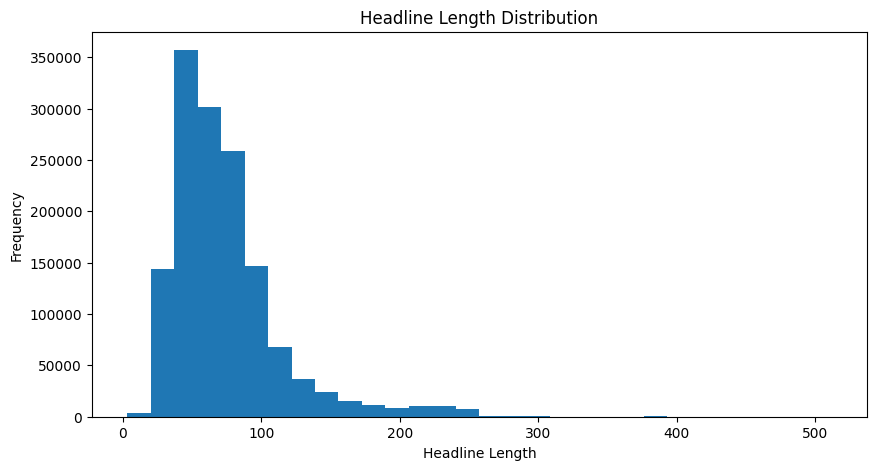

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(df["headline_length"], bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

In [36]:
top_publishers = df["publisher"].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

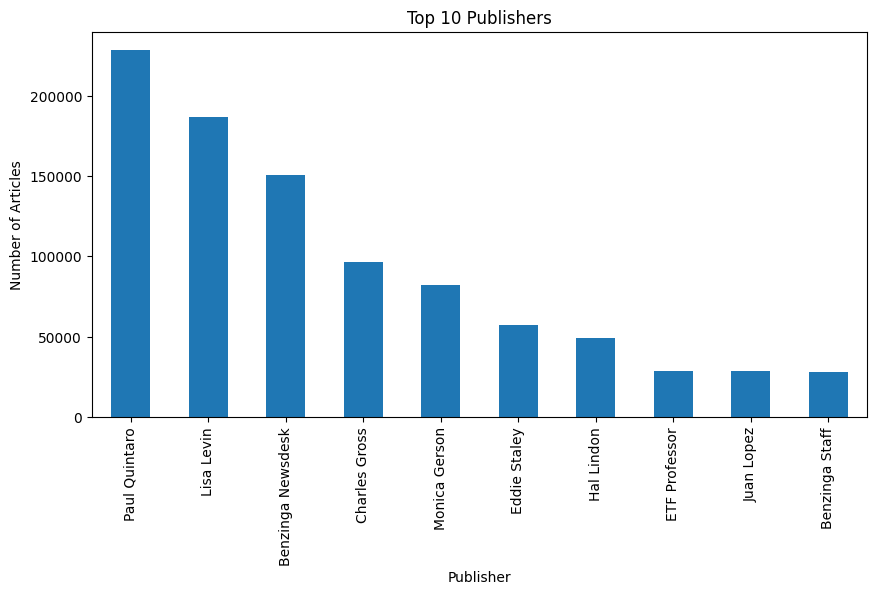

In [37]:
plt.figure(figsize=(10, 5))

top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.show()

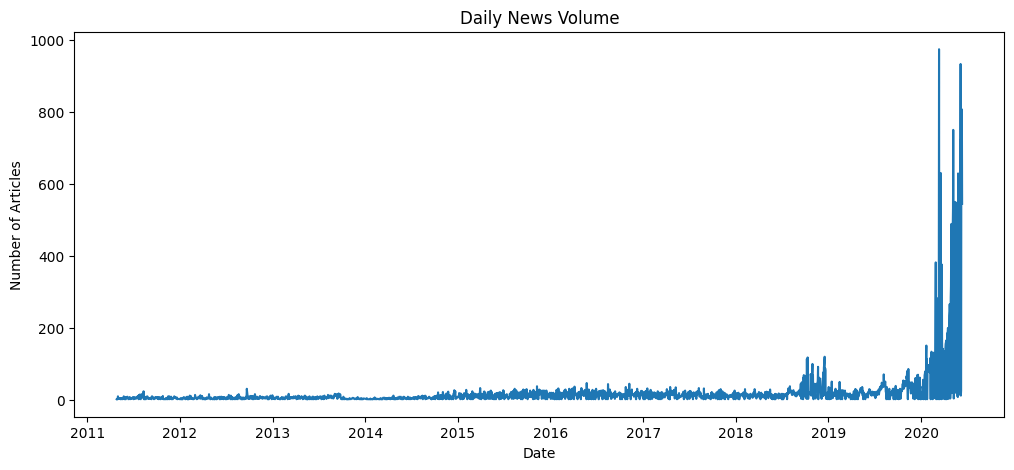

In [39]:
daily_news = df.groupby(df["date"].dt.date).size()
plt.figure(figsize=(12, 5))

daily_news.plot()

plt.title("Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [40]:
df["hour"] = df["date"].dt.hour
hourly_counts = df["hour"].value_counts().sort_index()

hourly_counts

hour
0.0       67
1.0       14
2.0       57
3.0       93
4.0     1469
5.0     1829
6.0     2476
7.0     5033
8.0     5527
9.0     5965
10.0    7669
11.0    5701
12.0    5732
13.0    2710
14.0    2075
15.0    1612
16.0    3939
17.0    2800
18.0     704
19.0     227
20.0     131
21.0      82
22.0      48
23.0      27
Name: count, dtype: int64

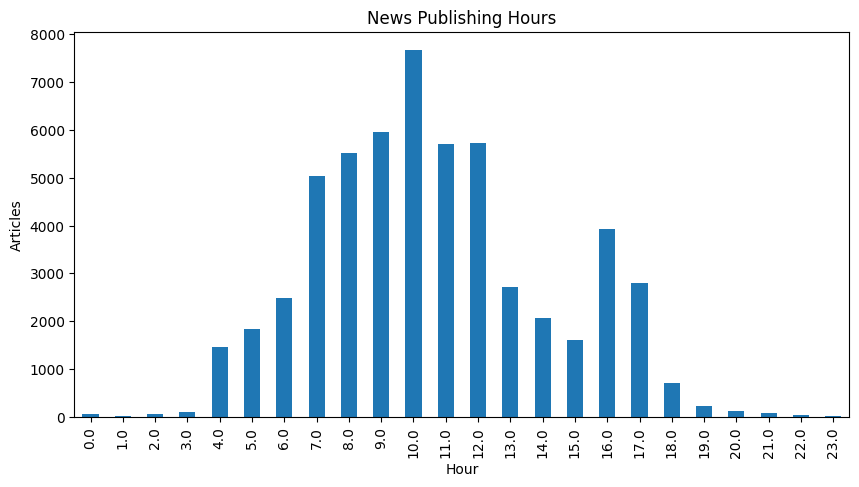

In [42]:
plt.figure(figsize=(10, 5))

hourly_counts.plot(kind="bar")

plt.title("News Publishing Hours")
plt.xlabel("Hour")
plt.ylabel("Articles")

plt.show()

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["headline"])
words = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A1
keywords = pd.DataFrame({
    "word": words,
    "score": scores
})

keywords = keywords.sort_values(by="score", ascending=False)

keywords.head(20)

,word,score
93662,stocks,0.025531
63981,market,0.018987
21105,benzinga,0.018465
104259,vs,0.016295
37999,earnings,0.015905
40857,est,0.015025
105161,week,0.014019
40388,eps,0.013495
36947,downgrades,0.013467
101828,upgrades,0.012928


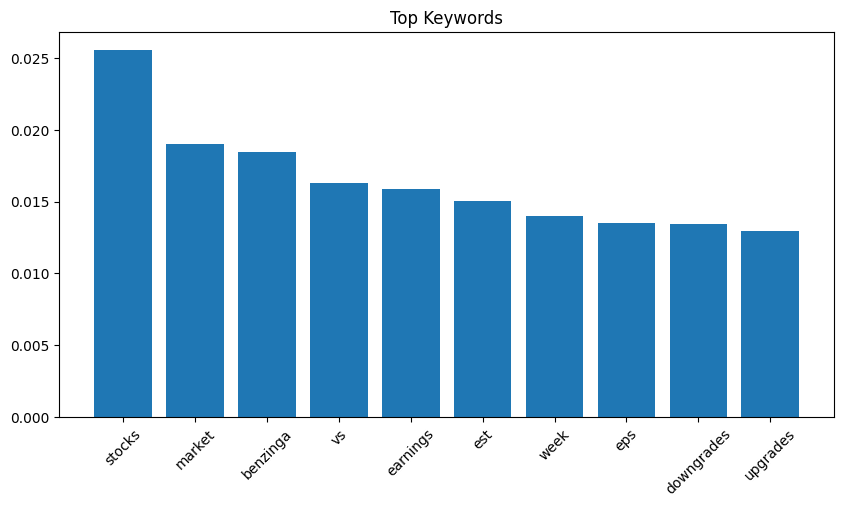

In [44]:
top_keywords = keywords.head(10)

plt.figure(figsize=(10, 5))

plt.bar(top_keywords["word"], top_keywords["score"])

plt.title("Top Keywords")
plt.xticks(rotation=45)

plt.show()